In [ ]:
import os
import time
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

from tqdm.notebook import tqdm

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

COMBINED_DIR       = "/content/drive/MyDrive/combined_dataset/train"
REALWORLD_TEST_DIR = "/content/drive/MyDrive/realworld_test"

SELECTED_CLASSES = [
    "Tomato___Early_blight",
    "Tomato___Late_blight",
    "Tomato___healthy",
    "Tomato___Tomato_Yellow_Leaf_Curl_Virus",
    "Tomato___Leaf_Mold",
]

IMG_SIZE      = 128
BATCH_SIZE    = 64
NUM_EPOCHS    = 25
LEARNING_RATE = 0.001
NUM_CLASSES   = len(SELECTED_CLASSES)
RANDOM_SEED   = 42

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device  : {DEVICE}")
print(f"Classes : {NUM_CLASSES}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Device  : cuda
Classes : 5


In [ ]:
train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),

    # Geometric augmentations
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.3),
    transforms.RandomRotation(degrees=15),

    # Scale/crop — model must classify even partial leaf views
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.7, 1.0)),

    # Colour augmentations — forces texture-based learning over colour memorisation
    transforms.ColorJitter(
        brightness=0.4,
        contrast=0.4,
        saturation=0.4,
    ),

    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),

    # RandomErasing: randomly blacks out a patch of the image during training.
    # Forces model not to rely on a single region
    transforms.RandomErasing(p=0.3, scale=(0.02, 0.15)),
])

# Eval/test transforms (resize and normalize)
eval_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

print("Train transforms: Flip + Rotate + ResizedCrop + ColorJitter + RandomErasing")
print("Eval  transforms: Resize + Normalize only")

Train transforms: Flip + Rotate + ResizedCrop + ColorJitter + RandomErasing
Eval  transforms: Resize + Normalize only


In [ ]:
full_dataset = datasets.ImageFolder(
    root=COMBINED_DIR,
    transform=train_transforms
)

# Filter for 5 selected tomato classes
selected_idx = [full_dataset.class_to_idx[c] for c in SELECTED_CLASSES]
label_remap  = {old: new for new, old in enumerate(selected_idx)}

filtered_samples = [
    (path, label_remap[label])
    for path, label in full_dataset.samples
    if label in selected_idx
]

full_dataset.samples      = filtered_samples
full_dataset.targets      = [l for _, l in filtered_samples]
full_dataset.classes      = SELECTED_CLASSES
full_dataset.class_to_idx = {c: i for i, c in enumerate(SELECTED_CLASSES)}

print(f"Total images: {len(full_dataset)}")
print()
for cls in SELECTED_CLASSES:
    idx   = full_dataset.class_to_idx[cls]
    count = sum(1 for _, l in full_dataset.samples if l == idx)
    print(f"  {cls:<52} {count:>5} images")

Total images: 11356

  Tomato___Early_blight                                 1079 images
  Tomato___Late_blight                                  2010 images
  Tomato___healthy                                      1650 images
  Tomato___Tomato_Yellow_Leaf_Curl_Virus                5580 images
  Tomato___Leaf_Mold                                    1037 images


# Stratified Train Test Split

In [ ]:
all_indices = list(range(len(full_dataset)))
all_targets = full_dataset.targets

train_idx, temp_idx = train_test_split(
    all_indices, test_size=0.30,
    stratify=all_targets, random_state=RANDOM_SEED
)
temp_targets = [all_targets[i] for i in temp_idx]
val_idx, test_idx = train_test_split(
    temp_idx, test_size=0.50,
    stratify=temp_targets, random_state=RANDOM_SEED
)

# Training subset uses augmented transforms
train_dataset = Subset(full_dataset, train_idx)

# Val and test subsets need eval transforms without augmentation
# Create a separate dataset instance with eval_transforms for this
eval_dataset = datasets.ImageFolder(
    root=COMBINED_DIR,
    transform=eval_transforms
)
eval_dataset.samples      = filtered_samples
eval_dataset.targets      = [l for _, l in filtered_samples]
eval_dataset.classes      = SELECTED_CLASSES
eval_dataset.class_to_idx = {c: i for i, c in enumerate(SELECTED_CLASSES)}

val_dataset  = Subset(eval_dataset, val_idx)
test_dataset = Subset(eval_dataset, test_idx)

print(f"Train : {len(train_dataset):>5} images  (augmented)")
print(f"Val   : {len(val_dataset):>5} images  (no augmentation)")
print(f"Test  : {len(test_dataset):>5} images  (no augmentation)")

Train :  7949 images  (augmented)
Val   :  1703 images  (no augmentation)
Test  :  1704 images  (no augmentation)


In [ ]:
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                          shuffle=True,  num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=0, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=0, pin_memory=True)

print(f"Train batches : {len(train_loader)}")
print(f"Val batches   : {len(val_loader)}")
print(f"Test batches  : {len(test_loader)}")

Train batches : 125
Val batches   : 27
Test batches  : 27


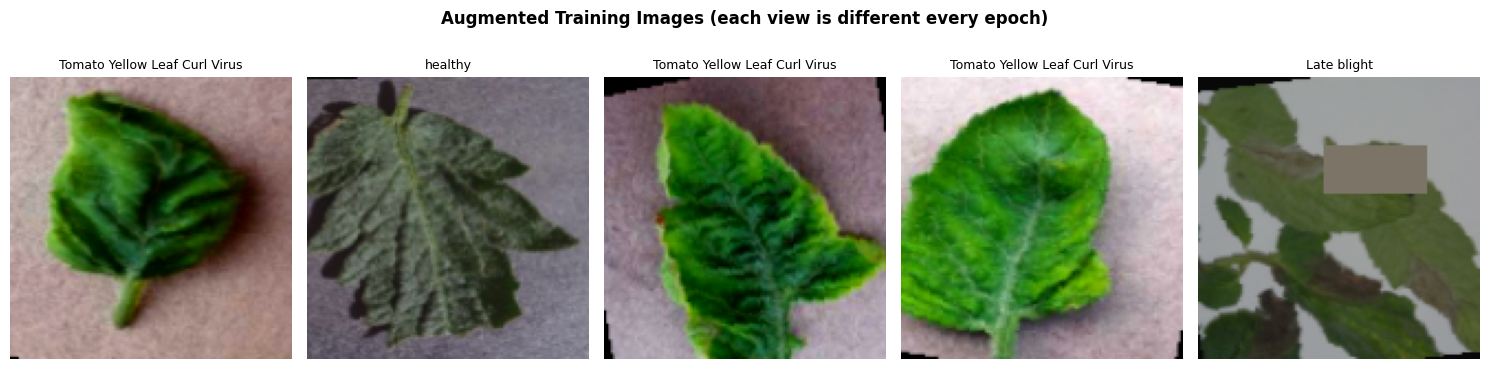

In [ ]:
mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
std  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)

images, labels = next(iter(train_loader))
images_disp = (images[:5] * std + mean).clamp(0, 1)

fig, axes = plt.subplots(1, 5, figsize=(15, 4))
for i, ax in enumerate(axes):
    ax.imshow(images_disp[i].permute(1, 2, 0).numpy())
    cls_name = SELECTED_CLASSES[labels[i]].replace("Tomato___","").replace("_"," ")
    ax.set_title(cls_name, fontsize=9)
    ax.axis("off")
plt.suptitle("Augmented Training Images (each view is different every epoch)",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("improved_augmented_samples.png", dpi=150)
plt.show()

In [ ]:
label_counts  = Counter(full_dataset.targets)
total_samples = sum(label_counts.values())

class_weights = torch.tensor([
    total_samples / (NUM_CLASSES * label_counts[i])
    for i in range(NUM_CLASSES)
], dtype=torch.float).to(DEVICE)

print("Class weights (higher = rarer class, penalised more):")
for i, cls in enumerate(SELECTED_CLASSES):
    short = cls.replace("Tomato___","").replace("_"," ")
    print(f"  {short:<40} count={label_counts[i]:>5}  weight={class_weights[i].item():.4f}")

Class weights (higher = rarer class, penalised more):
  Early blight                             count= 1079  weight=2.1049
  Late blight                              count= 2010  weight=1.1300
  healthy                                  count= 1650  weight=1.3765
  Tomato Yellow Leaf Curl Virus            count= 5580  weight=0.4070
  Leaf Mold                                count= 1037  weight=2.1902


In [ ]:
class ImprovedCNN(nn.Module):
    def __init__(self, num_classes=5):
        super(ImprovedCNN, self).__init__()

        self.features = nn.Sequential(

            # Block 1: 3 → 32
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),                  # 128 → 64

            # Block 2: 32 → 64
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),                  # 64 → 32

            # Block 3: 64 → 128
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),                  # 32 → 16

            # Block 4: 128 → 256 with double conv
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),                  # 16 → 8

            # Block 5: 256 → 512
            nn.Conv2d(256, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),                  # 8 → 4
        )

        # With IMG_SIZE=128 and 5 pooling layers: 128/32 = 4
        # AdaptivePool to 2x2 to keep classifier small
        self.adaptive_pool = nn.AdaptiveAvgPool2d((2, 2))  # → 2x2

        self.classifier = nn.Sequential(
            nn.Flatten(),                          # 512*2*2 = 2048
            nn.Linear(512 * 2 * 2, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.adaptive_pool(x)
        x = self.classifier(x)
        return x

model = ImprovedCNN(num_classes=NUM_CLASSES).to(DEVICE)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters     : {total_params:,}")
print(f"Trainable parameters : {trainable_params:,}")

Total parameters     : 3,212,805
Trainable parameters : 3,212,805


In [ ]:
criterion = nn.CrossEntropyLoss(weight=class_weights)

optimizer = optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', factor=0.5, patience=5
)

print("Loss      : CrossEntropyLoss (class-weighted)")
print("Optimizer : Adam  (lr={}, weight_decay=1e-4)".format(LEARNING_RATE))
print("Scheduler : ReduceLROnPlateau (factor=0.5, patience=5)")

Loss      : CrossEntropyLoss (class-weighted)
Optimizer : Adam  (lr=0.001, weight_decay=1e-4)
Scheduler : ReduceLROnPlateau (factor=0.5, patience=5)


In [ ]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    pbar = tqdm(loader, desc="  Training", leave=False)
    for images, labels in pbar:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, predicted  = outputs.max(1)
        total        += labels.size(0)
        correct      += predicted.eq(labels).sum().item()
        pbar.set_postfix(loss=f"{running_loss/total:.4f}",
                         acc=f"{100.*correct/total:.1f}%")

    return running_loss / total, 100. * correct / total


def validate(model, loader, criterion, device):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss    = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            _, predicted  = outputs.max(1)
            total        += labels.size(0)
            correct      += predicted.eq(labels).sum().item()

    return running_loss / total, 100. * correct / total

print("Helper functions defined!")

Helper functions defined!


In [ ]:
history = {
    "train_loss": [], "train_acc": [],
    "val_loss"  : [], "val_acc"  : [],
    "lr"        : []
}

best_val_acc = 0.0
best_epoch   = 0

print(f"{'Epoch':>6} | {'Train Loss':>10} | {'Train Acc':>9} | "
      f"{'Val Loss':>8} | {'Val Acc':>8} | {'LR':>8} | {'Time':>6}")
print("-" * 75)

for epoch in range(NUM_EPOCHS):
    start = time.time()

    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, DEVICE)
    val_loss,   val_acc   = validate(model, val_loader, criterion, DEVICE)

    scheduler.step(val_acc)
    current_lr = optimizer.param_groups[0]['lr']

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    history["lr"].append(current_lr)

    elapsed = time.time() - start
    print(f"{epoch+1:>6} | {train_loss:>10.4f} | {train_acc:>8.2f}% | "
          f"{val_loss:>8.4f} | {val_acc:>7.2f}% | {current_lr:>8.6f} | {elapsed:>5.1f}s")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_epoch   = epoch + 1
        torch.save(model.state_dict(), "improved_cnn_best.pth")
        print(f"         *Best model saved (val acc: {best_val_acc:.2f}%)")

print(f"\nTraining complete.")
print(f"Best val accuracy : {best_val_acc:.2f}%  at epoch {best_epoch}")

 Epoch | Train Loss | Train Acc | Val Loss |  Val Acc |       LR |   Time
---------------------------------------------------------------------------


  Training:   0%|          | 0/125 [00:00<?, ?it/s]

     1 |     1.3170 |    51.68% |   0.9011 |   71.93% | 0.001000 | 3024.6s
         *Best model saved (val acc: 71.93%)


  Training:   0%|          | 0/125 [00:00<?, ?it/s]

     2 |     0.9141 |    70.35% |   0.6286 |   82.50% | 0.001000 |  86.5s
         *Best model saved (val acc: 82.50%)


...

    23 |     0.2441 |    93.14% |   0.2107 |   94.19% | 0.001000 |  85.3s


  Training:   0%|          | 0/125 [00:00<?, ?it/s]

    24 |     0.2265 |    93.14% |   0.1956 |   94.07% | 0.001000 |  85.1s


  Training:   0%|          | 0/125 [00:00<?, ?it/s]

    25 |     0.2124 |    93.86% |   0.2036 |   92.95% | 0.001000 |  85.0s

Training complete.
Best val accuracy : 95.42%  at epoch 22


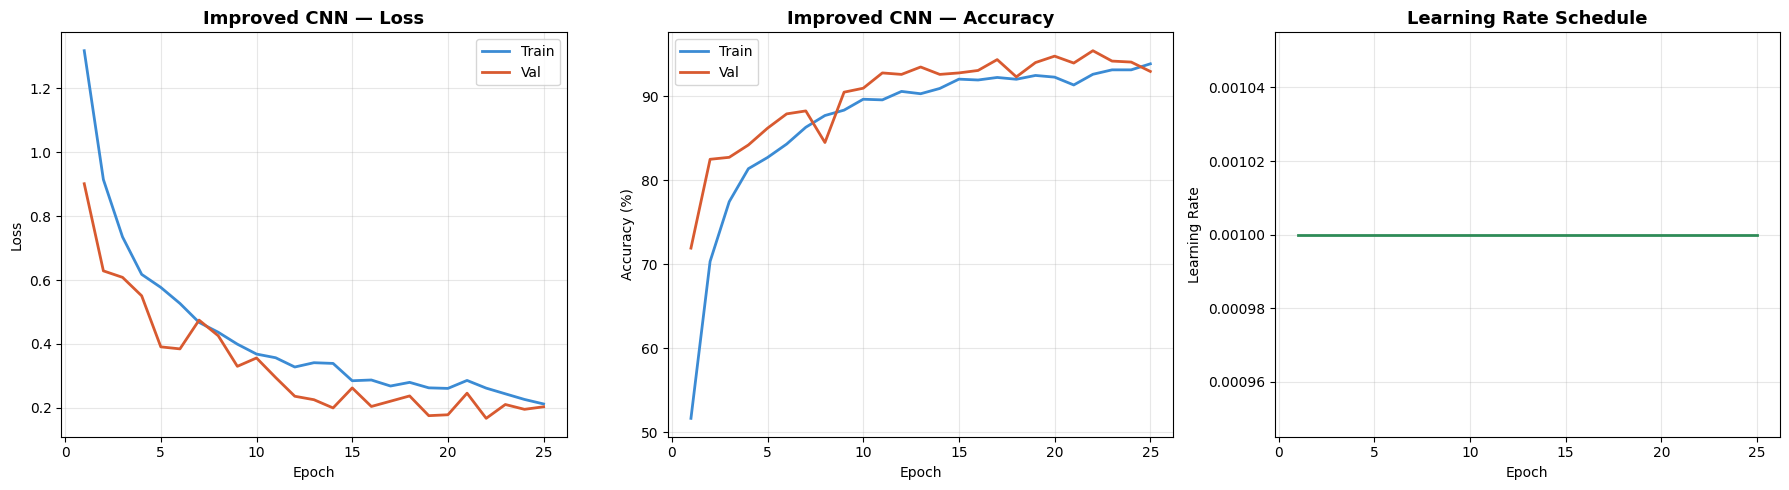

In [ ]:
epochs_range = range(1, NUM_EPOCHS + 1)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(epochs_range, history["train_loss"], label="Train", color="#3B8BD4", linewidth=2)
axes[0].plot(epochs_range, history["val_loss"],   label="Val",   color="#D85A30", linewidth=2)
axes[0].set_title("Improved CNN — Loss", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(epochs_range, history["train_acc"], label="Train", color="#3B8BD4", linewidth=2)
axes[1].plot(epochs_range, history["val_acc"],   label="Val",   color="#D85A30", linewidth=2)
axes[1].set_title("Improved CNN — Accuracy", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy (%)")
axes[1].legend(); axes[1].grid(alpha=0.3)

axes[2].plot(epochs_range, history["lr"], color="#2E8B57", linewidth=2)
axes[2].set_title("Learning Rate Schedule", fontsize=13, fontweight="bold")
axes[2].set_xlabel("Epoch"); axes[2].set_ylabel("Learning Rate")
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("improved_training_curves.png", dpi=150)
plt.show()

In [ ]:
model.load_state_dict(torch.load("improved_cnn_best.pth", map_location=DEVICE))
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for images, labels in test_loader:
        images  = images.to(DEVICE)
        outputs = model(images)
        _, predicted = outputs.max(1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

test_acc = 100. * (all_preds == all_labels).sum() / len(all_labels)
short_names = [c.replace("Tomato___","").replace("_"," ") for c in SELECTED_CLASSES]

print(f"Improved CNN — Standard Test Accuracy: {test_acc:.2f}%")
print()
print(classification_report(all_labels, all_preds,
                             target_names=short_names, digits=4))

Improved CNN — Standard Test Accuracy: 96.13%

                               precision    recall  f1-score   support

                 Early blight     0.8713    0.9198    0.8949       162
                  Late blight     0.9290    0.9536    0.9412       302
                      healthy     0.9960    0.9919    0.9939       248
Tomato Yellow Leaf Curl Virus     0.9963    0.9677    0.9818       837
                    Leaf Mold     0.8896    0.9355    0.9119       155

                     accuracy                         0.9613      1704
                    macro avg     0.9364    0.9537    0.9448      1704
                 weighted avg     0.9627    0.9613    0.9618      1704



In [ ]:
# Save model weights
torch.save(model.state_dict(), "improved_cnn_best.pth")
print("Model saved: improved_cnn_best.pth")

Model saved: improved_cnn_best.pth


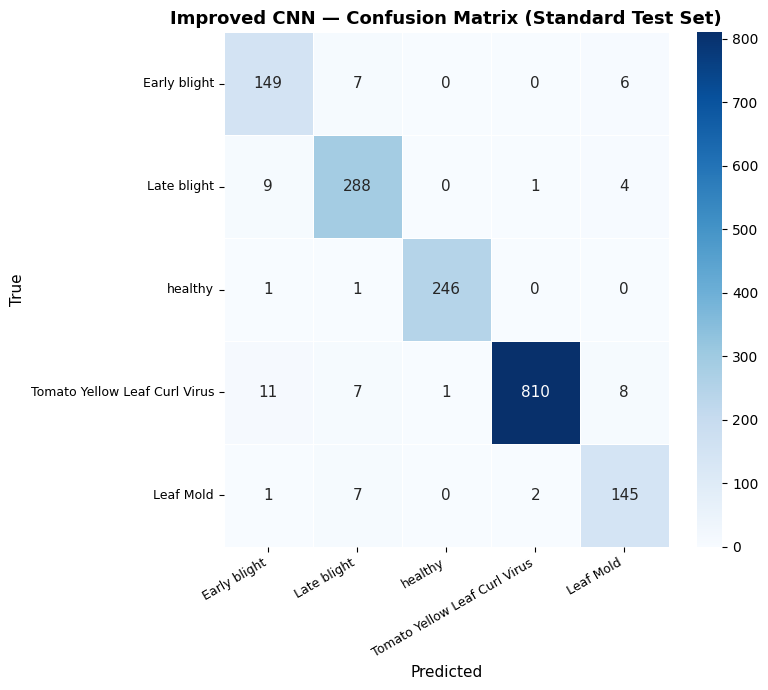

In [ ]:
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 7))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=short_names, yticklabels=short_names,
            linewidths=0.5, annot_kws={"size": 11})
plt.title("Improved CNN — Confusion Matrix (Standard Test Set)",
          fontsize=13, fontweight="bold")
plt.xlabel("Predicted", fontsize=11); plt.ylabel("True", fontsize=11)
plt.xticks(rotation=30, ha="right", fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.savefig("improved_confusion_matrix_standard.png", dpi=150)
plt.show()

Improved CNN — Real-World Test Accuracy: 45.83%

                               precision    recall  f1-score   support

                 Early blight     0.4000    0.6667    0.5000         9
                  Late blight     0.4000    0.4000    0.4000        10
                      healthy     1.0000    0.3750    0.5455         8
Tomato Yellow Leaf Curl Virus     0.6000    0.6000    0.6000        15
                    Leaf Mold     0.0000    0.0000    0.0000         6

                     accuracy                         0.4583        48
                    macro avg     0.4800    0.4083    0.4091        48
                 weighted avg     0.5125    0.4583    0.4555        48



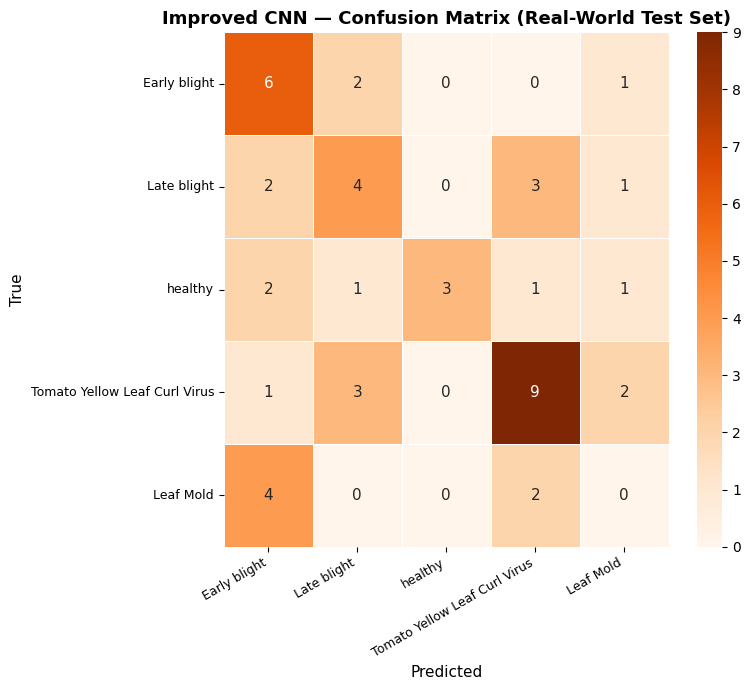

In [ ]:
if not os.path.exists(REALWORLD_TEST_DIR):
    print(f"Real-world test dir not found: {REALWORLD_TEST_DIR}")
else:
    rw_dataset = datasets.ImageFolder(root=REALWORLD_TEST_DIR,
                                       transform=eval_transforms)
    rw_dataset.class_to_idx = {c: i for i, c in enumerate(SELECTED_CLASSES)}
    rw_dataset.classes       = SELECTED_CLASSES
    rw_dataset.samples = [
        (p, rw_dataset.class_to_idx[os.path.basename(os.path.dirname(p))])
        for p, _ in rw_dataset.samples
        if os.path.basename(os.path.dirname(p)) in rw_dataset.class_to_idx
    ]
    rw_dataset.targets = [s[1] for s in rw_dataset.samples]

    rw_loader = DataLoader(rw_dataset, batch_size=BATCH_SIZE,
                           shuffle=False, num_workers=0)

    rw_preds, rw_labels = [], []
    model.eval()
    with torch.no_grad():
        for images, labels in rw_loader:
            images  = images.to(DEVICE)
            outputs = model(images)
            _, predicted = outputs.max(1)
            rw_preds.extend(predicted.cpu().numpy())
            rw_labels.extend(labels.numpy())

    rw_preds  = np.array(rw_preds)
    rw_labels = np.array(rw_labels)
    rw_acc = 100. * (rw_preds == rw_labels).sum() / len(rw_labels)

    print(f"Improved CNN — Real-World Test Accuracy: {rw_acc:.2f}%")
    print()
    print(classification_report(rw_labels, rw_preds,
                                 target_names=short_names, digits=4))

    rw_cm = confusion_matrix(rw_labels, rw_preds)
    plt.figure(figsize=(8, 7))
    sns.heatmap(rw_cm, annot=True, fmt="d", cmap="Oranges",
                xticklabels=short_names, yticklabels=short_names,
                linewidths=0.5, annot_kws={"size": 11})
    plt.title("Improved CNN — Confusion Matrix (Real-World Test Set)",
              fontsize=13, fontweight="bold")
    plt.xlabel("Predicted", fontsize=11); plt.ylabel("True", fontsize=11)
    plt.xticks(rotation=30, ha="right", fontsize=9)
    plt.yticks(rotation=0, fontsize=9)
    plt.tight_layout()
    plt.savefig("improved_confusion_matrix_realworld.png", dpi=150)
    plt.show()

In [ ]:
BASELINE_STANDARD  = 97.54
BASELINE_REALWORLD = 54.17

print("=" * 55)
print("MODEL COMPARISON — BASELINE vs IMPROVED CNN")
print("=" * 55)
print(f"{'Metric':<30} {'Baseline':>10} {'Improved':>10} {'Δ':>8}")
print("-" * 55)
print(f"{'Standard Test Accuracy':<30} {BASELINE_STANDARD:>9.2f}% {test_acc:>9.2f}% "
      f"{test_acc - BASELINE_STANDARD:>+7.2f}%")
try:
    print(f"{'Real-World Test Accuracy':<30} {BASELINE_REALWORLD:>9.2f}% {rw_acc:>9.2f}% "
          f"{rw_acc - BASELINE_REALWORLD:>+7.2f}%")
except:
    print("Real-world accuracy: run Cell 17 first")
print("=" * 55)

MODEL COMPARISON — BASELINE vs IMPROVED CNN
Metric                           Baseline   Improved        Δ
-------------------------------------------------------
Standard Test Accuracy             97.54%     96.13%   -1.41%
Real-World Test Accuracy           54.17%     45.83%   -8.34%


In [ ]:
print("=" * 60)
print("IMPROVED CNN — FINAL SUMMARY")
print("=" * 60)
print(f"Architecture     : 5-block CNN from scratch")
print(f"Parameters       : {sum(p.numel() for p in model.parameters()):,}")
print(f"Epochs trained   : {NUM_EPOCHS}")
print(f"Best val acc     : {best_val_acc:.2f}%  (epoch {best_epoch})")
print(f"Standard test acc: {test_acc:.2f}%")
print()
print("Key improvements over baseline:")
print("  + Data augmentation (Flip/Rotate/ColorJitter/RandomErasing)")
print("  + 5 conv blocks instead of 4")
print("  + Class-weighted loss")
print("  + Weight decay (L2 regularisation)")
print("  + Stronger dropout (0.5 vs 0.3)")
print("  + 30 epochs instead of 20")
print()
print("Output files saved:")
print("  improved_cnn_best.pth")
print("  improved_augmented_samples.png")
print("  improved_training_curves.png")
print("  improved_confusion_matrix_standard.png")
print("  improved_confusion_matrix_realworld.png")
print()

IMPROVED CNN — FINAL SUMMARY
Architecture     : 5-block CNN from scratch
Parameters       : 3,212,805
Epochs trained   : 25
Best val acc     : 95.42%  (epoch 22)
Standard test acc: 96.13%

Key improvements over baseline:
  + Data augmentation (Flip/Rotate/ColorJitter/RandomErasing)
  + 5 conv blocks instead of 4
  + Class-weighted loss
  + Weight decay (L2 regularisation)
  + Stronger dropout (0.5 vs 0.3)
  + 30 epochs instead of 20

Output files saved:
  improved_cnn_best.pth
  improved_augmented_samples.png
  improved_training_curves.png
  improved_confusion_matrix_standard.png
  improved_confusion_matrix_realworld.png

